In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

da = pd.read_excel('../../utaut2_dataset/utaut2_subsample.xlsx')

construct_names = {
    'PU': 'Воспринимаемая полезность',
    'PEOU': 'Лёгкость использования',
    'SI': 'Социальное влияние',
    'FC': 'Поддерживающие условия',
    'HM': 'Гедоническая мотивация',
    'PV': 'Ценность цены',
    'HAB': 'Привычка',
    'BI': 'Поведенческое намерение'
}

constructs = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB', 'BI']
predictors = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB']

# Пункты конструктов (нужны для Cronbach alpha)
df_full = pd.read_excel('../../utaut2_dataset/new_result.xlsx')
cols = df_full.columns.tolist()
construct_items = {
    'PU':   cols[13:16],
    'PEOU': cols[16:19],
    'SI':   cols[19:22],
    'FC':   cols[22:25],
    'HM':   cols[25:28],
    'PV':   cols[28:31],
    'HAB':  cols[31:34],
    'BI':   cols[34:37],
}

print(f'Аналитическая подвыборка UTAUT2: {len(da)}')

Аналитическая подвыборка UTAUT2: 164


In [2]:
import statsmodels.api as sm

X_ols = sm.add_constant(da[predictors])
model = sm.OLS(da['BI'], X_ols).fit()

regression_df = pd.DataFrame({
    'Переменная': model.params.index,
    'B': model.params.values,
    'SE': model.bse.values,
    't': model.tvalues.values,
    'p-value': model.pvalues.values
})

regression_df['B'] = regression_df['B'].round(3)
regression_df['SE'] = regression_df['SE'].round(3)
regression_df['t'] = regression_df['t'].round(3)
regression_df['p-value'] = regression_df['p-value'].apply(
    lambda x: f'{x:.2e}' if x < 0.001 else f'{x:.4f}'
)

print(f'R² модели = {model.rsquared:.3f}')
print(f'Adj. R² = {model.rsquared_adj:.3f}')
print(f'F-statistic = {model.fvalue:.2f}, p = {model.f_pvalue:.2e}\n')

regression_df

R² модели = 0.530
Adj. R² = 0.508
F-statistic = 25.09, p = 1.02e-22



,Переменная,B,SE,t,p-value
0,const,-0.904,0.522,-1.733,0.0851
1,PU,0.442,0.067,6.555,7.70e-10
2,PEOU,0.182,0.089,2.053,0.0418
3,SI,0.075,0.072,1.053,0.2940
4,FC,0.119,0.102,1.168,0.2446
5,HM,0.253,0.087,2.921,0.0040
6,PV,0.005,0.062,0.086,0.9313
7,HAB,0.173,0.034,5.122,8.83e-07


In [3]:
X_std = (da[predictors] - da[predictors].mean()) / da[predictors].std()
y_std = (da['BI'] - da['BI'].mean()) / da['BI'].std()

model_std = sm.OLS(y_std, sm.add_constant(X_std)).fit()

beta_df = pd.DataFrame({
    'Код': predictors,
    'Конструкт': [construct_names[c] for c in predictors],
    'β*': model_std.params[1:].values,
    'p-value': model_std.pvalues[1:].values
})

beta_df['β*'] = beta_df['β*'].round(3)
beta_df['Значимость'] = beta_df['p-value'].apply(
    lambda x: '***' if x < 0.001 else '**' if x < 0.01 else '*' if x < 0.05 else 'н.з.'
)
beta_df['p-value'] = beta_df['p-value'].apply(
    lambda x: f'{x:.2e}' if x < 0.001 else f'{x:.4f}'
)

beta_df.sort_values('β*', ascending=False)

,Код,Конструкт,β*,p-value,Значимость
0,PU,Воспринимаемая полезность,0.415,7.70e-10,***
6,HAB,Привычка,0.307,8.83e-07,***
4,HM,Гедоническая мотивация,0.191,0.0040,**
1,PEOU,Лёгкость использования,0.129,0.0418,*
2,SI,Социальное влияние,0.067,0.2940,н.з.
3,FC,Поддерживающие условия,0.067,0.2446,н.з.
5,PV,Ценность цены,0.005,0.9313,н.з.


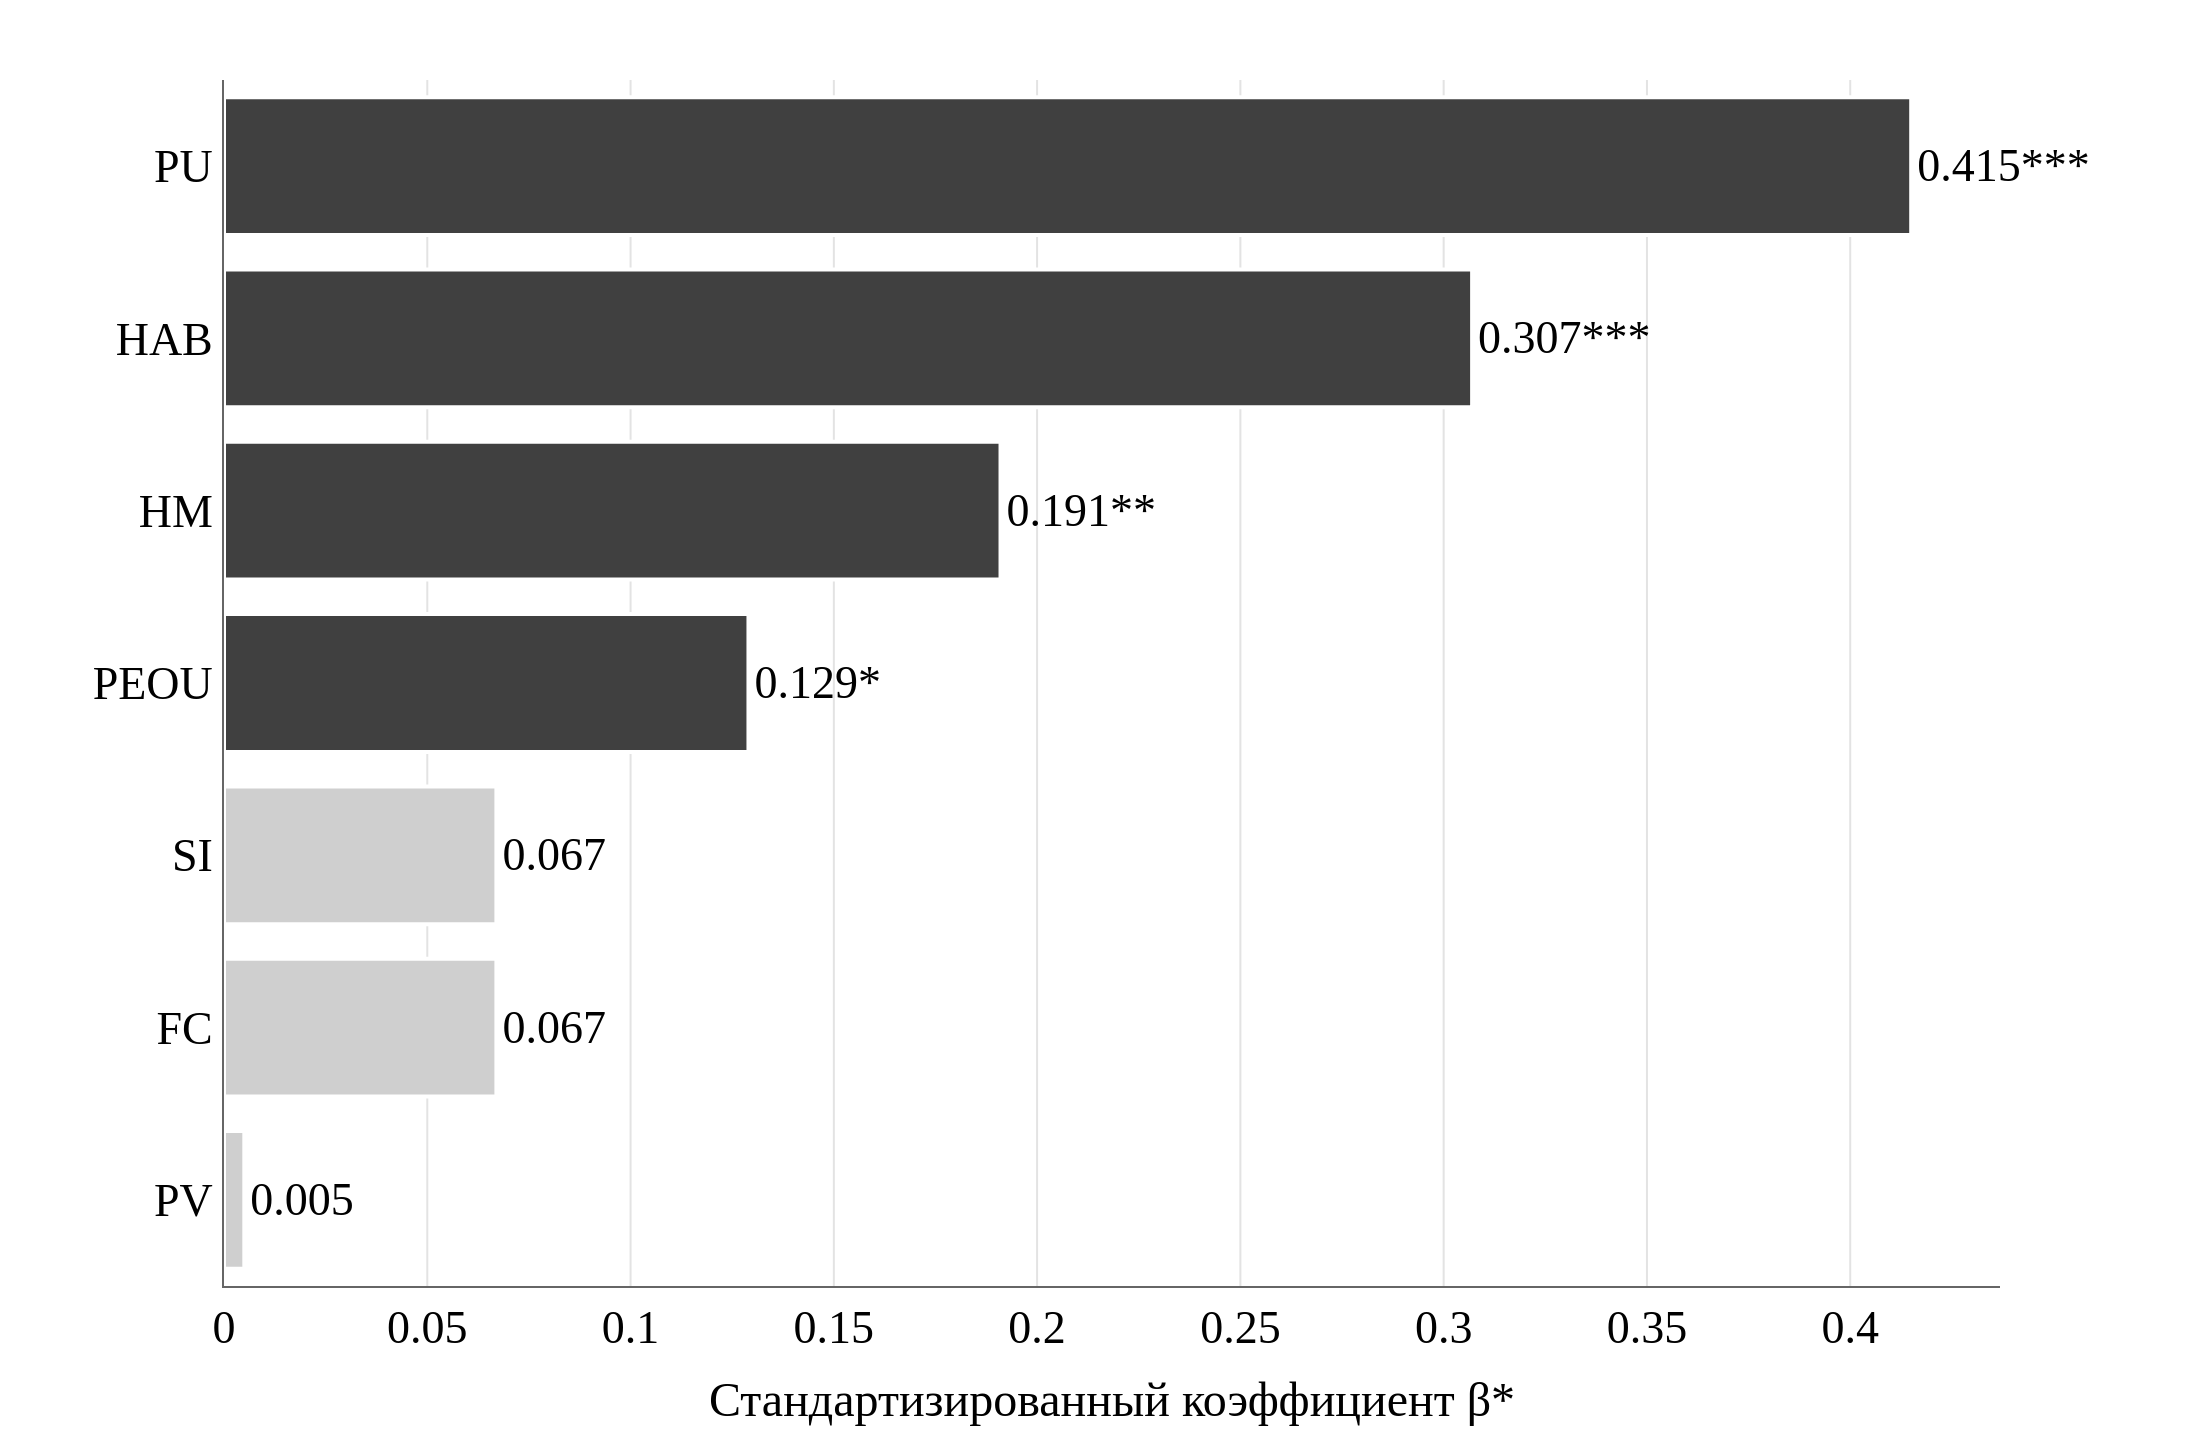

In [4]:
beta_plot = beta_df.sort_values('β*', ascending=True).copy()
colors = [PRIMARY if s != 'н.з.' else ACCENT_LIGHT for s in beta_plot['Значимость']]

fig = go.Figure(data=[go.Bar(
    y=beta_plot['Код'],
    x=beta_plot['β*'],
    orientation='h',
    text=[
        f'{b:.3f}{sig}' if sig != 'н.з.' else f'{b:.3f}'
        for b, sig in zip(beta_plot['β*'], beta_plot['Значимость'])
    ],
    textposition='outside',
    cliponaxis=False,
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(color=colors, line=dict(color='white', width=2)),
    hovertemplate='<b>%{y}</b><br>β* = %{x:.3f}<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        title=dict(text='Стандартизированный коэффициент β*', font=dict(size=24)),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=23),
        showgrid=False,
        linecolor=AXIS_COLOR,
        linewidth=1
    ),
    margin=dict(l=90, r=100, t=40, b=70),
    width=1100,
    height=720
)

fig.show()

In [5]:
print('Вывод по регрессии:\n')

for _, row in beta_df.sort_values('β*', ascending=False).iterrows():
    print(f"{row['Код']}: β* = {row['β*']:.3f}, p = {row['p-value']} ({row['Значимость']})")

print('\nМодель показывает, какие факторы сохраняют вклад в BI при одновременном учёте остальных конструктов.')

Вывод по регрессии:

PU: β* = 0.415, p = 7.70e-10 (***)
HAB: β* = 0.307, p = 8.83e-07 (***)
HM: β* = 0.191, p = 0.0040 (**)
PEOU: β* = 0.129, p = 0.0418 (*)
SI: β* = 0.067, p = 0.2940 (н.з.)
FC: β* = 0.067, p = 0.2446 (н.з.)
PV: β* = 0.005, p = 0.9313 (н.з.)

Модель показывает, какие факторы сохраняют вклад в BI при одновременном учёте остальных конструктов.
